Average y for 0.01 = 1.9101617792186754
Average y for 0.05 = 1.0178220080606892
Average y for 0.15 = 0.3197819117220568
Average y for 0.2 = 0.20447268245849218
Average y for 0.25 = 0.13579747480359125
Average y for 0.5 = 0.015873015873015872
Average y for 1 = 2.011791406600357


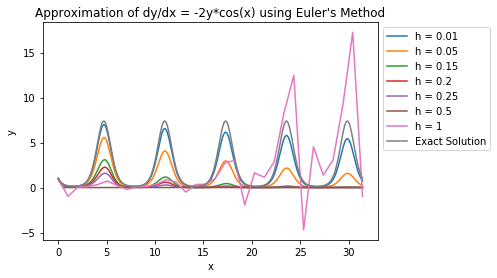

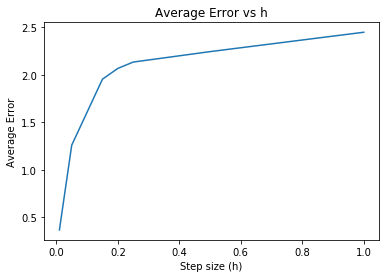

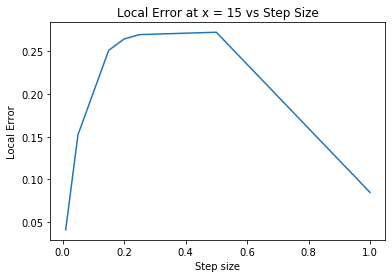

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
h = [0.01, 0.05, 0.15, 0.20, 0.25, 0.50, 1]  # chatgpt helped me find the remaining step size between .25 and 1
x_start, x_end = 0, 10*np.pi
def f(x, y):
    return -2 * y *np.cos(x)
err = []
avg_y = []
err_x15 = []
# Implement Euler's method
for i in range(len(h)):
    num_steps = int((x_end - x_start) / h[i])
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 1  # y(0) = 1
    
    for j in range(num_steps):
        y_values[j + 1] = y_values[j] + h[i] * f(x_values[j], y_values[j])
        
    y_exact = y_values [0] * np.exp(-2 * np.sin(x_values))  
    err.append(np.mean(np.abs(y_exact - y_values)))
    avg_y.append(np.mean(y_values))
    
    y15 = np.interp(15, x_values, y_values) 
    y15_exact = y_values [0] * np.exp(-2 * np.sin(15)) 
    err_x15.append(np.abs(y15_exact - y15))
    
    plt.plot(x_values, y_values, label = f'h = {h[i]}')

for k in range(len(h)):
    print(f'Average y for {h[k]} = {avg_y[k]}')
                 
# Plot the results
exact_x = np.linspace(x_start, x_end, 1000)
exact_y = np.exp(-2 * np.sin(exact_x))
plt.plot(exact_x, exact_y, label = 'Exact Solution')

plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title("Approximation of dy/dx = -2y*cos(x) using Euler's Method")

plt.figure()
plt.plot(h, err)
plt.title('Average Error vs h')
plt.xlabel('Step size (h)')
plt.ylabel('Average Error')

plt.figure()
plt.plot(h, err_x15)
plt.title('Local Error at x = 15 vs Step Size')
plt.xlabel('Step size')
plt.ylabel('Local Error')

plt.show()

#For the most part, as step size increases the Euler Method becomes less accurate for oscillating functions. For the local error as the step size increases, the estimation becomes more unstable and diverges from the actual solution.